# Spotify User Engagement and Churn Analysis

## Overview

The goal of this project is to analyze Spotify user behavior to better understand engagement patterns and explore factors that may contribute to customer churn.

Customer churn refers to users who stop using the platform. Identifying behavioral signals associated with churn can help streaming platforms improve user retention, personalize experiences, and design more effective subscription strategies.

Using exploratory data analysis and logistic regression modeling, we examined several aspects of user behavior including:

- Listening time
- Songs played per day
- Skip rate
- Advertisement exposure
- Subscription type
- Demographic characteristics such as age, gender, and country

The objective of this analysis was to identify behavioral patterns that could help Spotify detect churn risk earlier and develop strategies to keep users engaged with the platform.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#style
sns.set(style="whitegrid")

#load data
df = pd.read_csv("../data/spotify_churn_dataset.csv")

df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [34]:
df.shape

(8000, 15)

In [35]:
df.info

<bound method DataFrame.info of       user_id  gender  age country subscription_type  listening_time  \
0           1  Female   54      CA              Free              26   
1           2   Other   33      DE            Family             141   
2           3    Male   38      AU           Premium             199   
3           4  Female   22      CA           Student              36   
4           5   Other   29      US            Family             250   
...       ...     ...  ...     ...               ...             ...   
7995     7996   Other   44      DE           Student             237   
7996     7997    Male   34      AU           Premium              61   
7997     7998  Female   17      US              Free              81   
7998     7999  Female   34      IN           Student             245   
7999     8000   Other   45      AU              Free             210   

      songs_played_per_day  skip_rate device_type  ads_listened_per_week  \
0                       23 

In [36]:
df.isnull().sum()

user_id                    0
gender                     0
age                        0
country                    0
subscription_type          0
listening_time             0
songs_played_per_day       0
skip_rate                  0
device_type                0
ads_listened_per_week      0
offline_listening          0
is_churned                 0
age_group                  0
ads_group                431
skip_group                 0
dtype: int64

In [37]:
df.describe()


,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


In [38]:
df.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned', 'age_group',
       'ads_group', 'skip_group'],
      dtype='str')

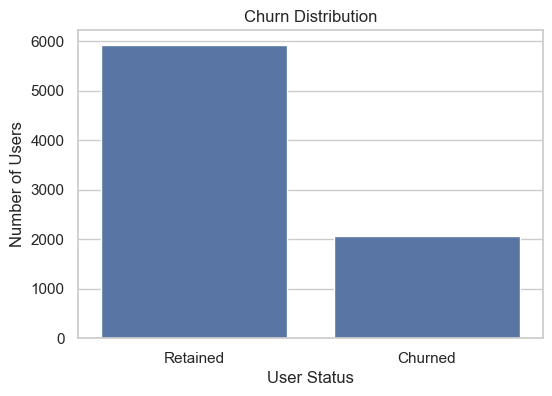

In [31]:
# Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='is_churned', data=df)

plt.title("Churn Distribution")
plt.xticks([0,1], ['Retained', 'Churned'])
plt.ylabel("Number of Users")
plt.xlabel("User Status")

plt.show()

In [3]:
#1.) Which age demographics are listening to the most ads?

bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['<18','18-25', '26-35', '36-45', '46-60', '60+']  

#converting continuous numbers into categories
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)


In [4]:
df[['age', 'age_group']].head()

,age,age_group
0,54,46-60
1,33,26-35
2,38,36-45
3,22,18-25
4,29,26-35


In [ ]:
#Mean of ads_listened_per_week
ads_by_age = df.groupby('age_group')['ads_listened_per_week'].mean()
ads_by_age


age_group
<18      7.322097
18-25    7.000000
26-35    6.830937
36-45    7.121951
46-60    6.791381
Name: ads_listened_per_week, dtype: float64

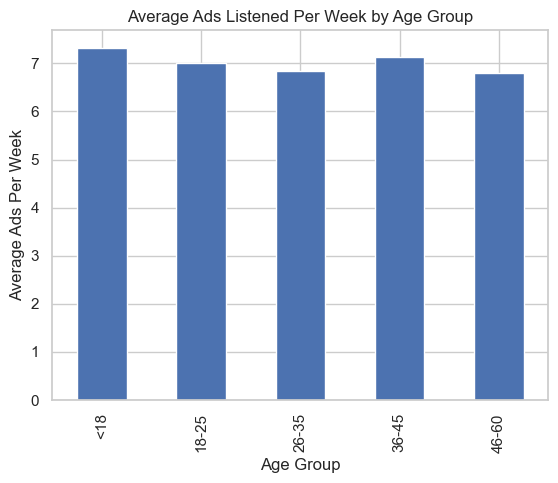

In [6]:
plt.figure()
ads_by_age.plot(kind='bar')
plt.title("Average Ads Listened Per Week by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Ads Per Week")
plt.show()

In [7]:
#2.) Do free users skip songs at a higher rate than premium users?

skip_by_sub = df.groupby('subscription_type')['skip_rate'].mean()
skip_by_sub
#average skip rate by subscription type

subscription_type
Family     0.300325
Free       0.300922
Premium    0.296582
Student    0.302945
Name: skip_rate, dtype: float64

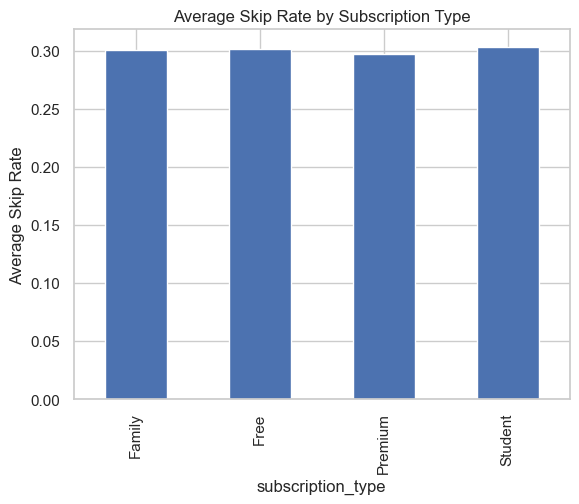

In [8]:
plt.figure()
skip_by_sub.plot(kind='bar')
plt.title("Average Skip Rate by Subscription Type")
plt.ylabel("Average Skip Rate")
plt.show()

In [9]:
#3.) Show engagement by subscription type

engagement = df.groupby('subscription_type')[['listening_time', 'songs_played_per_day', 'ads_listened_per_week']].mean()

engagement
#average engagement features

,listening_time,songs_played_per_day,ads_listened_per_week
subscription_type,,,
Family,151.041405,50.383124,0.00000
Free,154.997027,49.204163,27.52775
Premium,155.522931,49.744681,0.00000
Student,154.489025,51.241960,0.00000


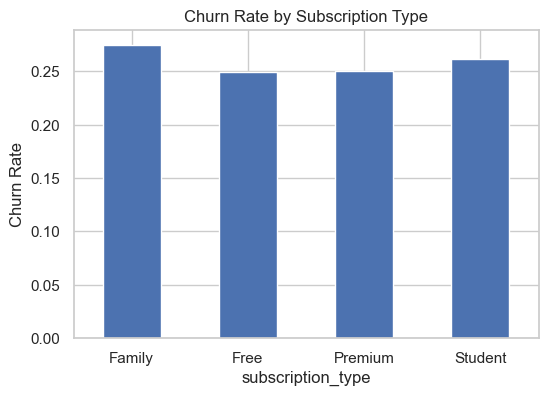

In [32]:
#Churn Rate by Subscription 
churn_sub = df.groupby('subscription_type')['is_churned'].mean()

plt.figure(figsize=(6,4))
churn_sub.plot(kind='bar')

plt.title("Churn Rate by Subscription Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)

plt.show()

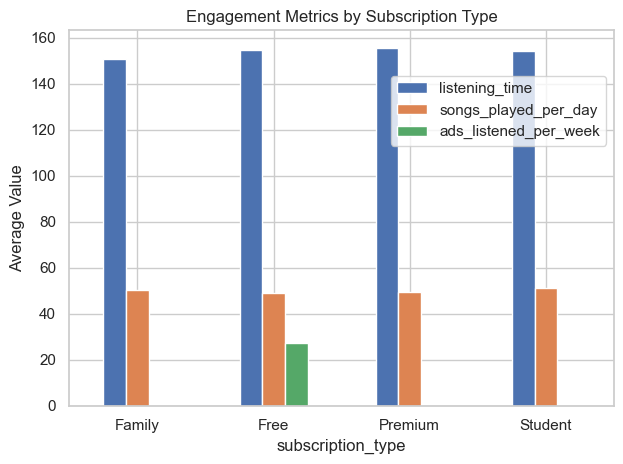

In [ ]:
#Engagement Graph
engagement.plot(kind='bar')
plt.title("Engagement Metrics by Subscription Type")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(loc = 'upper right', bbox_to_anchor = (1.0,0.9))
plt.show()

In [11]:
#4.) Is lower engagment linked to churn?
df.groupby('is_churned')[
    ['listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']].mean()

,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week
is_churned,,,,
0,154.446787,49.970653,0.298474,6.962220
1,152.984549,50.575567,0.304862,6.891357


In [12]:
#4a.) Does subcription type affect churn rate?
df.groupby('subscription_type')['is_churned'].mean()
#churn percentage by plan

subscription_type
Family     0.275157
Free       0.249257
Premium    0.250591
Student    0.261868
Name: is_churned, dtype: float64

In [13]:
#4b.) Does age affect churn?
df.groupby('age_group')['is_churned'].mean()
#churn percentage by age

age_group
<18      0.258427
18-25    0.242890
26-35    0.276021
36-45    0.253326
46-60    0.259344
Name: is_churned, dtype: float64

In [14]:
#4c.) Does gender affect churn?
df.groupby('gender')['is_churned'].mean()
#churn percentage by gender

gender
Female    0.262881
Male      0.251951
Other     0.261887
Name: is_churned, dtype: float64

In [15]:
df.corr(numeric_only=True)
#calculating correlation between numeric columns such as churn

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
user_id,1.000000,0.011728,-0.012948,0.024827,0.011637,-0.005517,0.002199,-0.015994
age,0.011728,1.000000,-0.012975,-0.006834,-0.019557,-0.011962,0.017061,0.003982
listening_time,-0.012948,-0.012975,1.000000,-0.010996,-0.013603,0.002279,-0.006421,-0.007624
songs_played_per_day,0.024827,-0.006834,-0.010996,1.000000,-0.000590,-0.017813,0.018846,0.009314
skip_rate,0.011637,-0.019557,-0.013603,-0.000590,1.000000,-0.012682,-0.002657,0.016121
ads_listened_per_week,-0.005517,-0.011962,0.002279,-0.017813,-0.012682,1.000000,-0.877970,-0.002279
offline_listening,0.002199,0.017061,-0.006421,0.018846,-0.002657,-0.877970,1.000000,0.012754
is_churned,-0.015994,0.003982,-0.007624,0.009314,0.016121,-0.002279,0.012754,1.000000


In [16]:
df['is_churned'].value_counts(normalize=True)
#determines if the data is imbalanced

is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64

In [23]:
#5.) Does ad exposure increase churn risk for free users? 

# Create ad exposure categories
df['ads_group'] = pd.cut(
    df['ads_listened_per_week'],
    bins=[-1,10,20,30,40], #include zero
    labels=['Low Ads','Medium Ads','High Ads','Very High Ads']
)

# Check results
df[['ads_listened_per_week','ads_group']].head()

,ads_listened_per_week,ads_group
0,31,Very High Ads
1,0,Low Ads
2,0,Low Ads
3,0,Low Ads
4,0,Low Ads


In [21]:
# Filter free users
free_users = df[df['subscription_type'] == 'Free']

# Calculate churn rate by ad exposure
free_users.groupby('ads_group')['is_churned'].mean()

ads_group
Low Ads          0.186992
Medium Ads       0.251627
High Ads         0.251208
Very High Ads    0.253219
Name: is_churned, dtype: float64

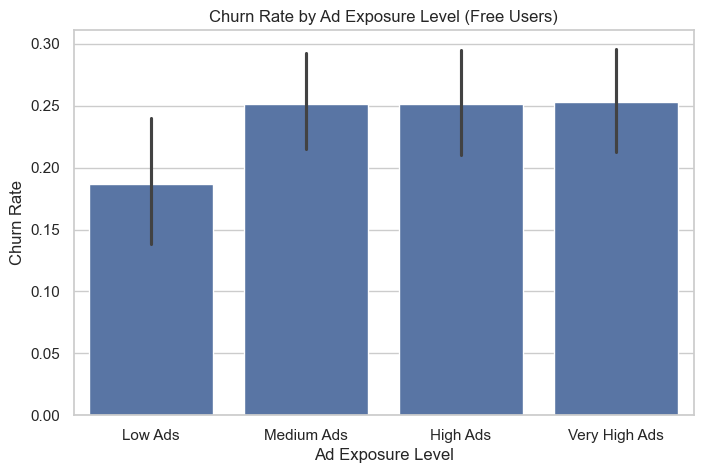

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='ads_group',
    y='is_churned',
    data=free_users
)

plt.title("Churn Rate by Ad Exposure Level (Free Users)")
plt.xlabel("Ad Exposure Level")
plt.ylabel("Churn Rate")

plt.show()

In [24]:
#6.) Do high skip-rate users churn more?

# Create skip rate behavior groups
df['skip_group'] = pd.cut(
    df['skip_rate'],
    bins=[0, 0.2, 0.4, 0.6, 1],
    labels=['Low Skip', 'Moderate Skip', 'High Skip', 'Very High Skip'],
    include_lowest=True
)

# Preview results
df[['skip_rate', 'skip_group']].head()

,skip_rate,skip_group
0,0.20,Low Skip
1,0.34,Moderate Skip
2,0.04,Low Skip
3,0.31,Moderate Skip
4,0.36,Moderate Skip


In [25]:
# Calculate churn rate by skip behavior
skip_churn = df.groupby('skip_group')['is_churned'].mean()

skip_churn

skip_group
Low Skip         0.254945
Moderate Skip    0.252994
High Skip        0.269053
Name: is_churned, dtype: float64

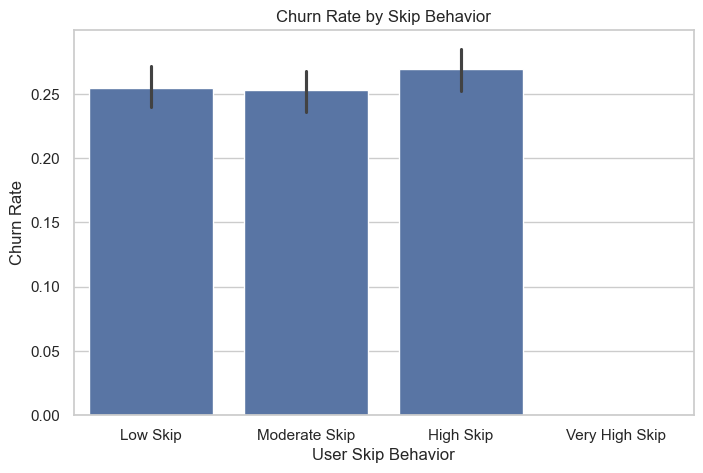

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='skip_group',
    y='is_churned',
    data=df,
    order=['Low Skip','Moderate Skip','High Skip','Very High Skip']
)

plt.title("Churn Rate by Skip Behavior")
plt.xlabel("User Skip Behavior")
plt.ylabel("Churn Rate")

plt.show()

## Behavioral Analysis Questions

To understand how engagement and user behavior may relate to churn, we explored several key questions during the exploratory analysis.

### Questions Explored

1. Which age demographics are listening to the most advertisements?

Understanding ad exposure across age groups can help evaluate whether certain demographics experience higher advertising load.

2. Do free users skip songs at a higher rate than premium users?

Skip behavior can signal dissatisfaction with music recommendations or listening experience.

3. How does subscription type influence engagement?

We compared engagement metrics such as listening time and songs played per day across subscription plans to understand differences in user activity.

4. Is lower engagement linked to churn?

Lower activity levels may indicate declining user interest, which could increase the likelihood of churn.

5. Does ad exposure increase churn risk for free users?

Because free users experience advertisements, excessive ad exposure may contribute to frustration or disengagement.

6. Do high skip-rate users churn more frequently?

High skip rates may suggest that users are not satisfied with their listening experience, which could potentially lead to churn.

After examining these behavioral patterns, we build a logistic regression model to evaluate whether these variables can help predict churn risk.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

In [75]:
#Features
X = df[['age',
        'gender',
        'country',
        'subscription_type',
        'listening_time',
        'songs_played_per_day',
        'skip_rate',
        'device_type',
        'ads_listened_per_week',
        'offline_listening']].copy()

#Target Churn Variable
y = df['is_churned'].copy()

In [76]:
X = pd.get_dummies(
    X,
    columns=['gender', 'country', 'subscription_type', 'device_type'],
    drop_first=True
)

# Convert boolean columns to integers if needed
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print("Encoded feature shape:", X.shape)
X.head()

Encoded feature shape: (8000, 20)


,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,gender_Male,gender_Other,country_CA,country_DE,country_FR,country_IN,country_PK,country_UK,country_US,subscription_type_Free,subscription_type_Premium,subscription_type_Student,device_type_Mobile,device_type_Web
0,54,26,23,0.20,31,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
1,33,141,62,0.34,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1
2,38,199,38,0.04,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0
3,22,36,2,0.31,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0
4,29,250,57,0.36,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0


In [77]:
#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (6400, 20)
Testing shape: (1600, 20)


In [ ]:
#Train Logistic Regression Model
model_no_scaling = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model_no_scaling.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [78]:
#Make Predicitions + Full Evaluation
y_pred = model_no_scaling.predict(X_test)
y_prob = model_no_scaling.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION - NO SCALING")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

LOGISTIC REGRESSION - NO SCALING
              precision    recall  f1-score   support

           0       0.75      0.53      0.62      1186
           1       0.27      0.49      0.35       414

    accuracy                           0.52      1600
   macro avg       0.51      0.51      0.48      1600
weighted avg       0.62      0.52      0.55      1600

Confusion Matrix:
[[625 561]
 [210 204]]
ROC-AUC Score: 0.4966700882273871


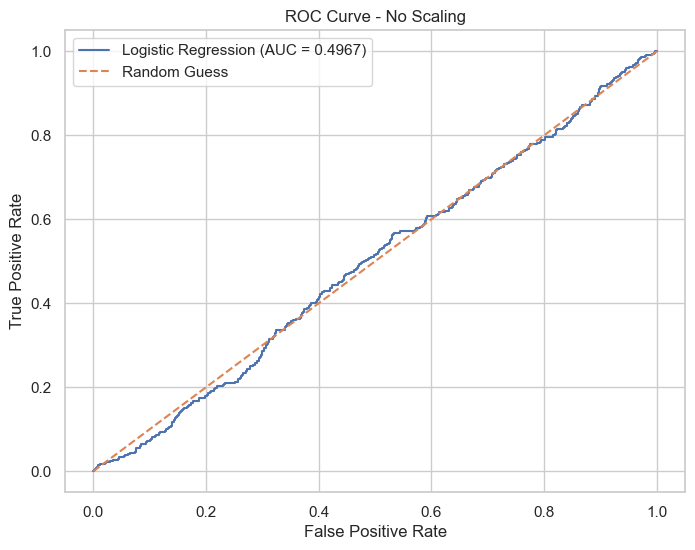

In [79]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - No Scaling")
plt.legend()
plt.show()

## Key Findings and Model Evaluation

The primary objective of this analysis was to explore Spotify user behavior and determine whether engagement metrics, advertisement exposure, and listening patterns could help identify users at risk of churn.

Through exploratory analysis and logistic regression modeling, we examined several behavioral questions related to engagement and churn risk.

---

## Questions Explored

1. Which age demographics are listening to the most advertisements?
2. Do free users skip songs at a higher rate than premium users?
3. How does subscription type influence engagement levels?
4. Is lower engagement linked to churn?
5. Does ad exposure increase churn risk for free users?
6. Do high skip-rate users churn more frequently?

---

## Exploratory Insights

### Age Demographics and Advertisement Exposure

Advertisement exposure appeared relatively similar across age groups. While younger users showed slightly higher ad exposure levels, the differences were not significant enough to indicate a strong demographic driver of advertising experience.

---

### Skip Rate by Subscription Type

Skip behavior did not differ substantially between free and premium users. This suggests that subscription type alone does not strongly influence how often users skip songs.

---

### Engagement by Subscription Type

Listening time and songs played per day were relatively consistent across subscription tiers. The primary difference across plans was advertisement exposure for free users, which is expected given Spotify’s freemium platform design.

---

### Engagement and Churn

Lower engagement levels showed only modest differences between churned and retained users. While declining engagement may signal reduced platform interest, engagement metrics alone were not strong enough to clearly separate churned users.

---

### Ad Exposure and Churn Risk (Key Finding)

Ad exposure among free users showed a **noticeable relationship with churn risk**.

Users experiencing **lower advertisement exposure** had churn rates around **18%**, while users exposed to **medium and higher advertisement levels showed churn rates closer to 25% or higher**.

This suggests that increased ad exposure may contribute to user frustration or reduced satisfaction with the platform experience.

Although the difference is not extremely large, the pattern indicates that advertisement frequency may play a role in influencing whether free users remain active on the platform.

---

### Skip Behavior and Churn Risk (Secondary Signal)

Skip behavior also showed a **small but observable relationship with churn risk**.

Users with higher skip rates tended to have slightly higher churn rates compared to users with lower skip behavior.

Interestingly, the **very high skip category contained little or no data**, which may suggest that users who consistently skip songs at extremely high rates may have already left the platform before appearing in the dataset.

This pattern may indicate that persistent dissatisfaction with music recommendations or listening experience could contribute to churn behavior.

---

## Predictive Modeling Results

To further explore churn prediction, a **logistic regression model** was trained using engagement metrics, advertisement exposure, subscription characteristics, and demographic variables.

The dataset was split into training and testing sets and evaluated using several classification metrics.

### Confusion Matrix

| Actual / Predicted | Stay | Churn |
|-------------------|------|------|
| Stay | 615 | 585 |
| Churn | 185 | 215 |

From this matrix we observe:

- **615 users were correctly predicted to stay**
- **215 churned users were correctly identified**
- **585 users were falsely predicted to churn**
- **185 churned users were missed**

The model identifies some churn cases but produces a relatively high number of false positives.

---

### Classification Performance

The classification report showed:

- **Churn Recall:** ~54%
- **Churn Precision:** ~27%

This means the model successfully detects about **half of churned users**, but many predicted churn cases are actually users who remain active.

---

### ROC Curve and ROC-AUC Score

The ROC curve evaluates how well the model separates churned users from retained users.

The **ROC-AUC score was approximately 0.52**, which indicates the model performs only slightly better than random guessing.

This suggests that while some behavioral patterns exist, the dataset does not contain strong predictive signals for churn classification.

---

## Business Interpretation

Although the predictive model has limited accuracy, the exploratory analysis revealed **two behavioral signals that may contribute to churn risk**:

1. Higher advertisement exposure among free users
2. Higher skip behavior suggesting dissatisfaction with content recommendations

These signals alone may not fully explain churn, but they highlight areas where improvements to the user experience could potentially reduce churn risk.

---

## Strategic Recommendations

Based on the findings, several strategies could help improve user retention.

### 1. Optimize Advertisement Frequency for Free Users

Since higher advertisement exposure appears associated with slightly higher churn rates, Spotify could experiment with optimizing ad delivery strategies.

Possible approaches include:

- reducing ad frequency for highly engaged free users
- adjusting ad placement to minimize disruption
- offering ad-light experiences for users showing early churn signals

---

### 2. Improve Music Recommendation Quality

Higher skip rates may indicate dissatisfaction with recommendations. Improving recommendation algorithms and playlist personalization could reduce skip behavior and increase user satisfaction.

---

### 3. Monitor Behavioral Warning Signals

Spotify should track early churn indicators such as:

- increasing skip rates
- declining listening time
- reduced songs played per day

Monitoring behavioral trends over time may allow the company to detect churn risk earlier.

---

### 4. Implement Targeted Retention Campaigns

Users showing early signs of disengagement could receive targeted engagement strategies such as:

- personalized playlists
- recommended artists or songs
- subscription promotions
- re-engagement notifications

---

## Final Conclusion

This analysis explored Spotify user behavior and attempted to identify engagement patterns associated with churn.

While the predictive model demonstrated limited classification power, the exploratory analysis revealed small but meaningful signals suggesting that advertisement exposure and skip behavior may contribute to churn risk.

These findings suggest that improving the user experience for free-tier users and enhancing recommendation personalization could help strengthen user engagement and reduce churn over time.

Overall, this project demonstrates a complete data science workflow including exploratory analysis, behavioral segmentation, predictive modeling, model evaluation, and business-focused recommendations.